In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
DATASET_DIR = "/Users/swastikabhusal/Documents/CNN_project/CATS_DOGS"

print("Dataset exists:", os.path.exists(DATASET_DIR))

Dataset exists: False


In [3]:
print("Current working directory:")
print(os.getcwd())

Current working directory:
/Users/swastikabhusal/Documents/practice days/Leroy AI project/Cats & Dog


In [4]:
print("\nFolders here:")
print(os.listdir("."))


Folders here:
['.DS_Store', 'training.ipynb', 'dataset', '2nd.ipynb', '.ipynb_checkpoints']


In [5]:
import os

matches = []

for root, dirs, files in os.walk(os.path.expanduser("~")):
    if "CATS_DOGS" in dirs:
        matches.append(os.path.join(root, "CATS_DOGS"))

print("Found datasets:")
for path in matches:
    print(path)

Found datasets:
/Users/swastikabhusal/Documents/practice days/Leroy AI project/CATS_DOGS


In [12]:


DATASET_DIR = "/Users/swastikabhusal/Documents/practice days/Leroy AI project/CATS_DOGS"

print("Dataset exists:", os.path.exists(DATASET_DIR))

Dataset exists: True


In [14]:
print(os.listdir(DATASET_DIR))

['Untitled1.ipynb', '.DS_Store', 'test', 'Untitled.ipynb', 'train', '.ipynb_checkpoints']


In [16]:
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
TEST_DIR = os.path.join(DATASET_DIR, "test")

print("Train folders:")
print(os.listdir(TRAIN_DIR))

print("\nTest folders:")
print(os.listdir(TEST_DIR))

Train folders:
['CAT', '.DS_Store', 'DOG']

Test folders:
['CAT', '.DS_Store', 'DOG']


In [18]:
import os

cat_train = len(os.listdir(os.path.join(TRAIN_DIR, "CAT")))
dog_train = len(os.listdir(os.path.join(TRAIN_DIR, "DOG")))

cat_test = len(os.listdir(os.path.join(TEST_DIR, "CAT")))
dog_test = len(os.listdir(os.path.join(TEST_DIR, "DOG")))

print("Training images:", cat_train + dog_train)
print("Testing images:", cat_test + dog_test)

print("\nCat training images:", cat_train)
print("Dog training images:", dog_train)

print("\nCat testing images:", cat_test)
print("Dog testing images:", dog_test)


Training images: 18743
Testing images: 6251

Cat training images: 9371
Dog training images: 9372

Cat testing images: 3126
Dog testing images: 3125


In [20]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 18743 files belonging to 2 classes.
Found 6251 files belonging to 2 classes.


In [22]:
print("Class names:", train_dataset.class_names)

Class names: ['CAT', 'DOG']


In [24]:
#checking one batch of image
for images, labels in train_dataset.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)
    print("Image data type:", images.dtype)
    print("First 10 labels:", labels[:10].numpy().flatten())

Image shape: (32, 128, 128, 3)
Label shape: (32, 1)
Image data type: <dtype: 'float32'>
First 10 labels: [1. 0. 1. 0. 0. 0. 0. 1. 0. 0.]


2026-08-24 13:16:30.251382: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [26]:
# Normalize the image 
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [28]:
for images, labels in train_dataset.take(1):
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


2026-08-24 13:17:01.320929: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [30]:
# Defining the CNN models
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
#Compiling the model 
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [38]:
#Train
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10
 45/586 ━━━━━━━━━━━━━━━━━━━━ 1:22 152ms/step - accuracy: 0.5031 - loss: 0.7181

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


 64/586 ━━━━━━━━━━━━━━━━━━━━ 1:19 152ms/step - accuracy: 0.5082 - loss: 0.7124

Corrupt JPEG data: 252 extraneous bytes before marker 0xd9


112/586 ━━━━━━━━━━━━━━━━━━━━ 1:10 150ms/step - accuracy: 0.5217 - loss: 0.7041

InvalidArgumentError: Graph execution error:

Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
Input size should match (header_size + row_size * abs_height) but they differ by 2
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]] [Op:__inference_one_step_on_iterator_2332]

In [40]:
# Lets find corrupt image
from PIL import Image
import os

bad_images = []

for folder in [TRAIN_DIR, TEST_DIR]:
    for class_name in ["CAT", "DOG"]:
        class_path = os.path.join(folder, class_name)

        for filename in os.listdir(class_path):
            filepath = os.path.join(class_path, filename)

            try:
                with Image.open(filepath) as img:
                    img.verify()
            except Exception:
                bad_images.append(filepath)

print("Number of bad images:", len(bad_images))

for image in bad_images:
    print(image)

/opt/anaconda3/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Number of bad images: 0


In [42]:
# Testing every image in tensorflow
import tensorflow as tf
import os

bad_tf_images = []

for folder in [TRAIN_DIR, TEST_DIR]:
    for class_name in ["CAT", "DOG"]:
        class_path = os.path.join(folder, class_name)

        for filename in os.listdir(class_path):
            filepath = os.path.join(class_path, filename)

            try:
                image = tf.io.read_file(filepath)
                image = tf.image.decode_image(
                    image,
                    channels=3,
                    expand_animations=False
                )
            except Exception as e:
                bad_tf_images.append((filepath, str(e)))

print("TensorFlow bad images:", len(bad_tf_images))

for filepath, error in bad_tf_images[:20]:
    print("\nFILE:", filepath)
    print("ERROR:", error)

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
2026-08-24 13:19:42.726041: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input size should match (header_size + row_size * abs_height) but they differ by 2
Corrupt JPEG data: 65 extraneous bytes before marker 0xd9
Corrupt JPEG data: 228 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 252 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
2026-08-24 13:19:56.858833: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INV

TensorFlow bad images: 7

FILE: /Users/swastikabhusal/Documents/practice days/Leroy AI project/CATS_DOGS/train/CAT/4351.jpg
ERROR: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input size should match (header_size + row_size * abs_height) but they differ by 2 [Op:DecodeImage] name: 

FILE: /Users/swastikabhusal/Documents/practice days/Leroy AI project/CATS_DOGS/train/DOG/2317.jpg
ERROR: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Number of channels inherent in the image must be 1, 3 or 4, was 2 [Op:DecodeImage] name: 

FILE: /Users/swastikabhusal/Documents/practice days/Leroy AI project/CATS_DOGS/train/DOG/2494.jpg
ERROR: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input size should match (header_size + row_size * abs_height) but they differ by 2 [Op:DecodeImage] name: 

FILE: /Users/swastikabhusal/Documents/practice days/Leroy AI project/CATS

In [44]:
# removing only corrupt image 
bad_files = [
    os.path.join(TRAIN_DIR, "CAT", "4351.jpg"),
    os.path.join(TRAIN_DIR, "DOG", "2317.jpg"),
    os.path.join(TRAIN_DIR, "DOG", "2494.jpg"),
    os.path.join(TEST_DIR, "CAT", "10404.jpg"),
    os.path.join(TEST_DIR, "DOG", "11912.jpg"),
    os.path.join(TEST_DIR, "DOG", "11233.jpg"),
    os.path.join(TEST_DIR, "DOG", "9500.jpg")
]

for filepath in bad_files:
    if os.path.exists(filepath):
        os.remove(filepath)
        print("Deleted:", filepath)
    else:
        print("Not found:", filepath)

Deleted: /Users/swastikabhusal/Documents/practice days/Leroy AI project/CATS_DOGS/train/CAT/4351.jpg
Deleted: /Users/swastikabhusal/Documents/practice days/Leroy AI project/CATS_DOGS/train/DOG/2317.jpg
Deleted: /Users/swastikabhusal/Documents/practice days/Leroy AI project/CATS_DOGS/train/DOG/2494.jpg
Deleted: /Users/swastikabhusal/Documents/practice days/Leroy AI project/CATS_DOGS/test/CAT/10404.jpg
Deleted: /Users/swastikabhusal/Documents/practice days/Leroy AI project/CATS_DOGS/test/DOG/11912.jpg
Deleted: /Users/swastikabhusal/Documents/practice days/Leroy AI project/CATS_DOGS/test/DOG/11233.jpg
Deleted: /Users/swastikabhusal/Documents/practice days/Leroy AI project/CATS_DOGS/test/DOG/9500.jpg


In [46]:
# Now recreating the dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 18740 files belonging to 2 classes.
Found 6247 files belonging to 2 classes.


In [48]:
#normalize again
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [50]:
# Training again
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10


Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9


 12/586 ━━━━━━━━━━━━━━━━━━━━ 1:24 148ms/step - accuracy: 0.5644 - loss: 0.6601

 53/586 ━━━━━━━━━━━━━━━━━━━━ 1:17 145ms/step - accuracy: 0.6041 - loss: 0.6497

Corrupt JPEG data: 228 extraneous bytes before marker 0xd9


...

502/586 ━━━━━━━━━━━━━━━━━━━━ 14s 178ms/step - accuracy: 0.9636 - loss: 0.0965

Corrupt JPEG data: 128 extraneous bytes before marker 0xd9


586/586 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9632 - loss: 0.0971

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 396 extraneous bytes before marker 0xd9


586/586 ━━━━━━━━━━━━━━━━━━━━ 117s 200ms/step - accuracy: 0.9632 - loss: 0.0972 - val_accuracy: 0.8561 - val_loss: 0.5095


In [52]:
#Evaluating the model
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

 68/196 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.8578 - loss: 0.5168

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9


159/196 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8584 - loss: 0.5141

Corrupt JPEG data: 396 extraneous bytes before marker 0xd9


196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.8580 - loss: 0.5132
Test Loss: 0.5095436573028564
Test Accuracy: 0.8560909032821655


In [54]:
#Printing the final training result
print("Final Training Accuracy:", history.history["accuracy"][-1])
print("Final Validation Accuracy:", history.history["val_accuracy"][-1])

print("Final Training Loss:", history.history["loss"][-1])
print("Final Validation Loss:", history.history["val_loss"][-1])

Final Training Accuracy: 0.9612593650817871
Final Validation Accuracy: 0.8560909032821655
Final Training Loss: 0.10007821768522263
Final Validation Loss: 0.5095436573028564


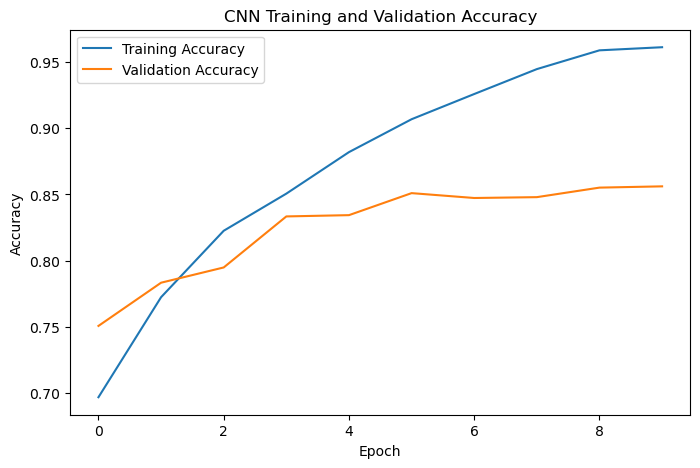

In [56]:
#Plotting accuracy 
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.show()

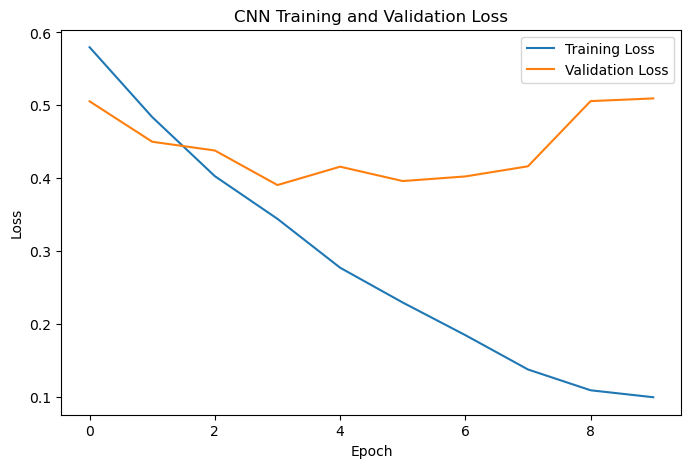

In [58]:
# plot loss 
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.show()

In [60]:
# now evaluating on actual test dataset
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

 68/196 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.8578 - loss: 0.5168

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9


160/196 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8583 - loss: 0.5141

Corrupt JPEG data: 396 extraneous bytes before marker 0xd9


196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.8580 - loss: 0.5132
Test Loss: 0.5095436573028564
Test Accuracy: 0.8560909032821655


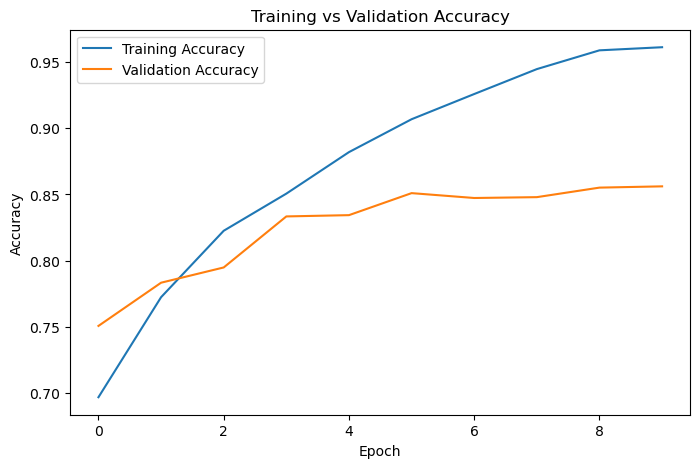

In [62]:
#creating accuracy/loss graph
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

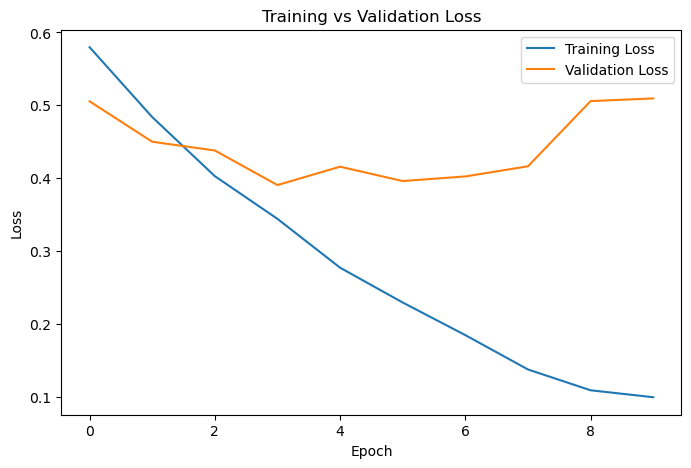

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [74]:

import os

cat_path = os.path.join(TRAIN_DIR, "CAT")

image_name = os.listdir(cat_path)[0]
IMAGE_PATH = os.path.join(cat_path, image_name)

print("Image name:", image_name)
print("Full path:", IMAGE_PATH)

Image name: 63.jpg
Full path: /Users/swastikabhusal/Documents/practice days/Leroy AI project/CATS_DOGS/train/CAT/63.jpg


In [78]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
img = load_img(IMAGE_PATH, target_size=IMG_SIZE)

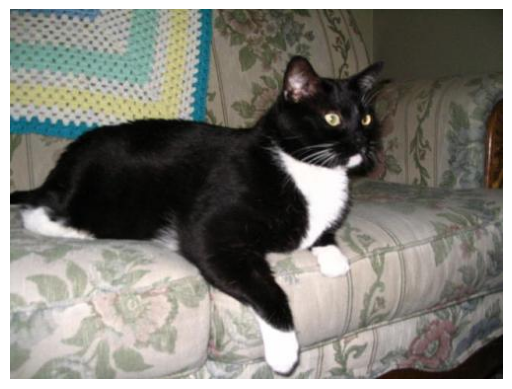

In [80]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(IMAGE_PATH)

plt.imshow(img)
plt.axis("off")
plt.show()

In [90]:
# prediction cat or dog
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

IMAGE_PATH = "/Users/swastikabhusal/Documents/practice days/Leroy AI project/CATS_DOGS/train/CAT/63.jpg"

img = load_img(IMAGE_PATH, target_size=IMG_SIZE)
img_array = img_to_array(img)

# Normalize in the same way used during training
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Prediction: [[0.00539151]]


In [92]:
#convert prediction into cat or dog
probability = prediction[0][0]

if probability >= 0.5:
    predicted_class = "DOG"
    confidence = probability
else:
    predicted_class = "CAT"
    confidence = 1 - probability

print("Predicted class:", predicted_class)
print("Confidence:", f"{confidence * 100:.2f}%")

Predicted class: CAT
Confidence: 99.46%


In [94]:
MODEL_PATH = "cat_dog_cnn.keras"

model.save(MODEL_PATH)

print("Model saved successfully!")
print("Location:", os.path.abspath(MODEL_PATH))

Model saved successfully!
Location: /Users/swastikabhusal/Documents/practice days/Leroy AI project/Cats & Dog/cat_dog_cnn.keras
